<a href="https://colab.research.google.com/github/Parthwadekar40/ParthCM40-Pattern-Recognition/blob/main/Prac4_PR_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the loan prediction dataset from a public URL
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    print("\nDataset Information:")
    print(df.info())
    print("\nDescriptive Statistics:")
    print(df.describe(include='all'))

    # --- Data Cleaning and Preprocessing --- #

    # Handle missing values
    # Impute categorical columns with mode
    for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
        if df[col].isnull().sum() > 0:
            # Using .loc to avoid FutureWarning about inplace operations on copies
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])

    # Impute numerical columns with mean (LoanAmount) or mode (Loan_Amount_Term)
    if df['LoanAmount'].isnull().sum() > 0:
        df.loc[:, 'LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
    if df['Loan_Amount_Term'].isnull().sum() > 0:
        df.loc[:, 'Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

    # Convert 'Dependents' column
    # Replace '3+' with '3' and convert to int
    df.loc[:, 'Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

    print("\n--- After handling missing values and converting types ---")
    print("Updated Dataset Information:")
    print(df.info())
    print("Missing values after imputation:")
    print(df.isnull().sum())

    # --- Feature Engineering and Data Splitting --- #

    # Drop Loan_ID as it is not needed for prediction
    df.drop('Loan_ID', axis=1, inplace=True)

    # Separate features (X) and target (y)
    X = df.drop('Loan_Status', axis=1)
    y = df['Loan_Status']

    # Convert categorical features to numerical using one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    # Encode the target variable (Loan_Status) to numerical (Y=1, N=0)
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Split the dataset into training and testing sets
    # Using a random state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\n--- After Feature Engineering and Data Splitting ---")
    print("Shape of X_train:", X_train.shape)
    print("Shape of X_test:", X_test.shape)
    print("Shape of y_train:", y_train.shape)
    print("Shape of y_test:", y_test.shape)
    print("First 5 rows of X_train (encoded features):")
    print(X_train.head())
    print("First 5 values of y_train (encoded target):")
    print(y_train[:5])

    # --- Model Training and Evaluation --- #

    print("\n--- Model Training and Evaluation ---")

    # Decision Tree Classifier
    dt_classifier = DecisionTreeClassifier(random_state=42)
    dt_classifier.fit(X_train, y_train)
    y_pred_dt = dt_classifier.predict(X_test)
    accuracy_dt = accuracy_score(y_test, y_pred_dt)
    print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")

    # K-Nearest Neighbors Classifier
    # Choosing a common value for n_neighbors, typically an odd number
    knn_classifier = KNeighborsClassifier(n_neighbors=5)
    knn_classifier.fit(X_train, y_train)
    y_pred_knn = knn_classifier.predict(X_test)
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    print(f"K-Nearest Neighbors Classifier Accuracy: {accuracy_knn:.4f}")

except Exception as e:
    print(f"Error loading or processing the dataset: {e}")
    print("Please ensure you have an active internet connection or try a different dataset URL.")

Dataset loaded successfully!

First 5 rows of the dataset:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1      

/tmp/ipykernel_804/3953699744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='viridis')


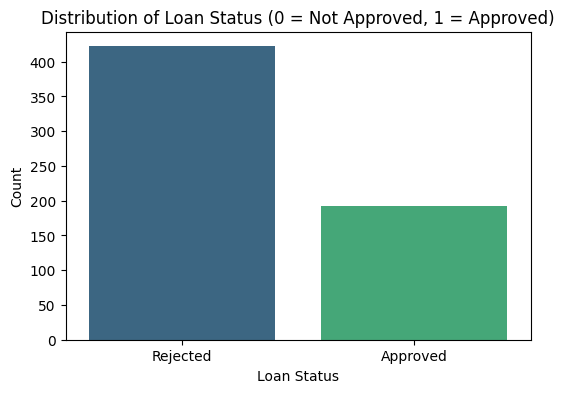

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df, palette='viridis')
plt.title('Distribution of Loan Status (0 = Not Approved, 1 = Approved)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.show()

### Exploring Numerical Features

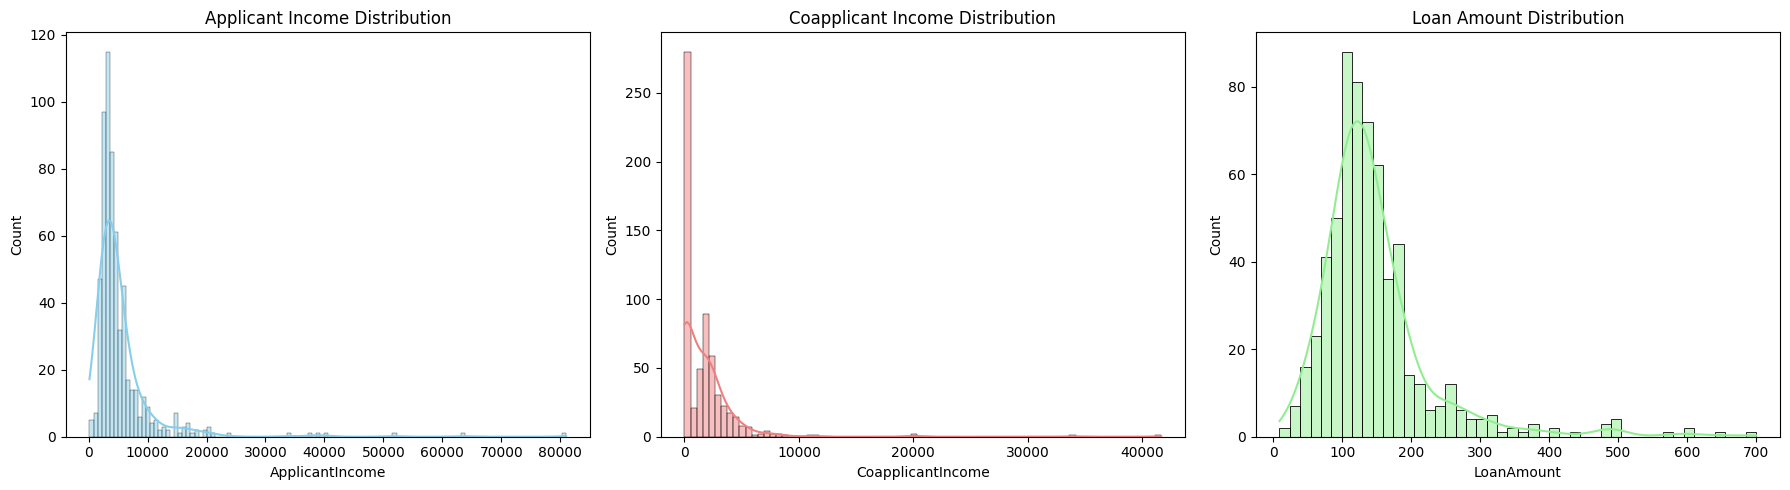

In [7]:
# Histograms for numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Applicant Income Distribution')

sns.histplot(df['CoapplicantIncome'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Coapplicant Income Distribution')

sns.histplot(df['LoanAmount'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Loan Amount Distribution')

plt.tight_layout()
plt.show()

### Exploring Categorical Features vs. Loan Status

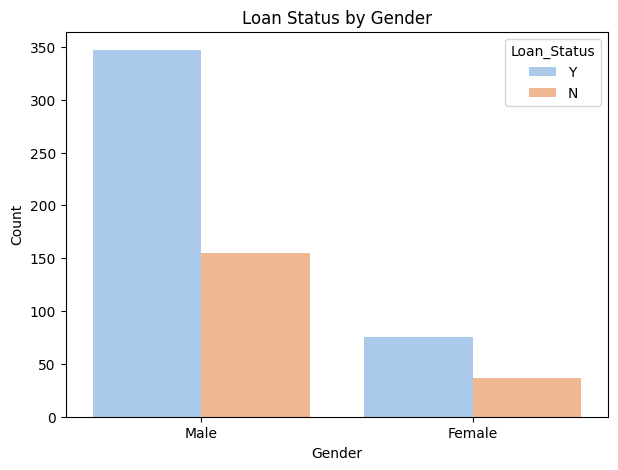

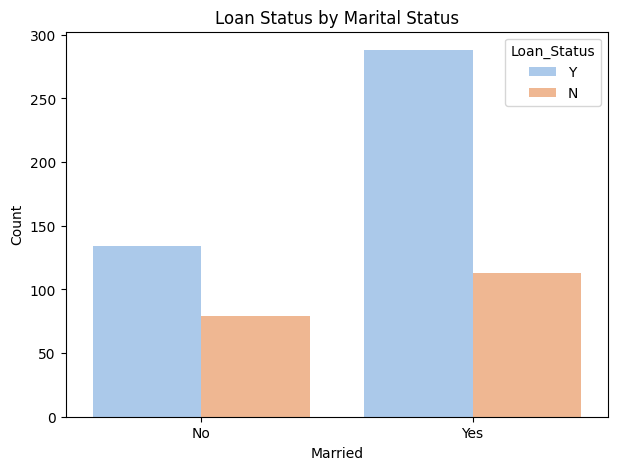

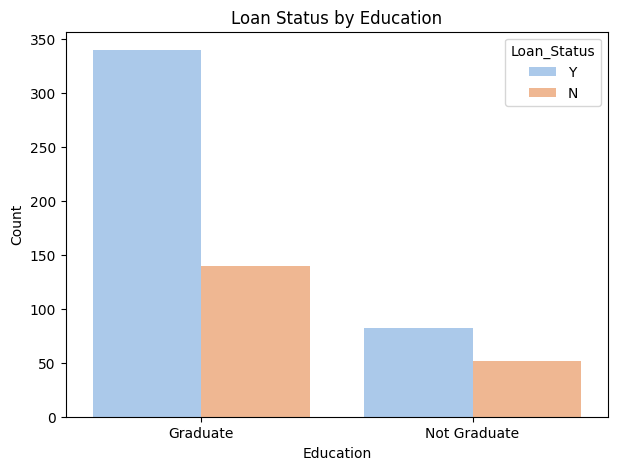

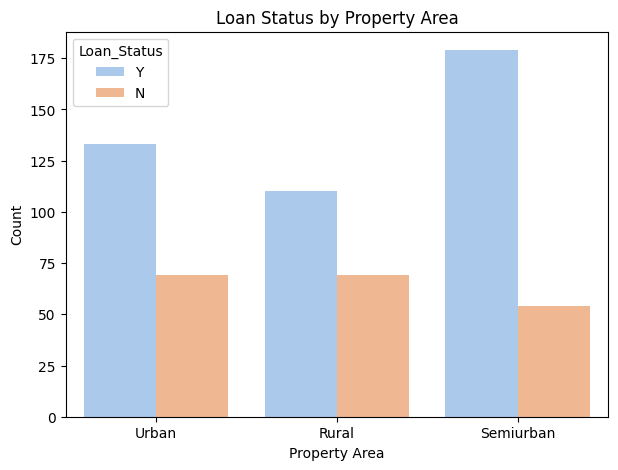

In [8]:
# Relationship between Gender and Loan Status
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', hue='Loan_Status', data=df, palette='pastel')
plt.title('Loan Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Relationship between Married and Loan Status
plt.figure(figsize=(7, 5))
sns.countplot(x='Married', hue='Loan_Status', data=df, palette='pastel')
plt.title('Loan Status by Marital Status')
plt.xlabel('Married')
plt.ylabel('Count')
plt.show()

# Relationship between Education and Loan Status
plt.figure(figsize=(7, 5))
sns.countplot(x='Education', hue='Loan_Status', data=df, palette='pastel')
plt.title('Loan Status by Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

# Relationship between Property_Area and Loan Status
plt.figure(figsize=(7, 5))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, palette='pastel')
plt.title('Loan Status by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.show()